In [8]:

from dotenv import load_dotenv
load_dotenv()



from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [18]:
#  Crearte LTM store + seed memories (done Before Running Graph)
store = InMemoryStore()

user_id="ui"


# Store user details as a single blob (simple for teaching)
# you cacn also split into multiple records; this keeps it easy
user_details = ("user",user_id,"details")


store.put(user_details, "profile_1", {"data": "Name: Nitish"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})


from langchain_google_genai import GoogleGenerativeAIEmbeddings,ChatGoogleGenerativeAI

In [20]:
llm1 = ChatGoogleGenerativeAI(
model="gemini-2.5-flash",
# temperature=0.2,
# max_tokens=100,   
# timeout=None,
# max_retries=2,
# other params...
)


In [6]:
from langchain_community.llms import Ollama

llm = Ollama(
    model="tinyllama",
    base_url="http://localhost:11434"
)

C:\Users\admin\AppData\Local\Temp\ipykernel_26460\3636385069.py:3: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(


In [7]:

# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [21]:
def chat_node(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id = config["configurable"]["user_id"]


    # Read-only: Fetch user details memomry (no writes)
    user_details = ("user",user_id,"details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_deatils_content}
    # Keep it dead simple for teaching

    if items:
        user_details_content = "\n".join(f"-{items.value.get('data','')}")
    else:
        user_details_content = "" #prompt say it may be empty

        system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details_content
        )

    system_msg = SystemMessage(content=system_prompt)
    response = llm1.invoke([system_msg]+state["messages"])

    return {"messages":[response]}

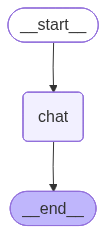

In [23]:
builder = StateGraph(MessagesState)
builder.add_node("chat",chat_node)
builder.add_edge(START,"chat")
builder.add_edge("chat",END)

graph = builder.compile(store=store)
graph

In [24]:

# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------

config = {"configurable":{"user_id":"u1"}}

result = graph.invoke(
    {"messages":[{"role":"user","content":"Explain physics ai in simple terms"}]},
    config
)

In [25]:
result["messages"]

[HumanMessage(content='Explain physics ai in simple terms', additional_kwargs={}, response_metadata={}, id='6223de37-4ab9-4c85-84cc-b19df4d0a5b9'),
 AIMessage(content='Hello there! I can definitely explain "physics AI" in simple terms for you.\n\nImagine you have a powerful brain (that\'s the AI) and a textbook full of rules about how the world works (that\'s physics). "Physics AI" is essentially about teaching that powerful AI brain to understand and use those physics rules.\n\nHere\'s a breakdown:\n\n1.  **Traditional AI/Machine Learning:** This usually learns by looking at tons of data and finding patterns. For example, it might learn to recognize cats by seeing millions of cat pictures.\n2.  **Physics-Informed AI:** Instead of just learning from data, we "tell" the AI about the fundamental laws of physics (like gravity, conservation of energy, how heat flows, etc.). This means the AI doesn\'t have to "discover" these laws from scratch; it already knows them as a baseline.\n\n**Why 

In [26]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [27]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()


In [ ]:

# ----------------------------
# 2) LLM that decides what to remember (structured output)
# ----------------------------